In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
# Load dataset
car_data = pd.read_csv('car data (1).csv')

# Display first 5 rows
print(car_data.head())

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  


In [3]:
# Shape of dataset
print("Dataset Shape:", car_data.shape)

# Dataset information
print(car_data.info())

# Statistical summary
print(car_data.describe())

# Check missing values
print(car_data.isnull().sum())

Dataset Shape: (301, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None
              Year  Selling_Price  Present_Price     Driven_kms       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.642584   38886.883882    0.247915
min    2003.0000

In [4]:
# Create new feature
current_year = 2026
car_data['Car_Age'] = current_year - car_data['Year']

# Remove Year column
car_data.drop('Year', axis=1, inplace=True)

print(car_data.head())

  Car_Name  Selling_Price  Present_Price  Driven_kms Fuel_Type Selling_type  \
0     ritz           3.35           5.59       27000    Petrol       Dealer   
1      sx4           4.75           9.54       43000    Diesel       Dealer   
2     ciaz           7.25           9.85        6900    Petrol       Dealer   
3  wagon r           2.85           4.15        5200    Petrol       Dealer   
4    swift           4.60           6.87       42450    Diesel       Dealer   

  Transmission  Owner  Car_Age  
0       Manual      0       12  
1       Manual      0       13  
2       Manual      0        9  
3       Manual      0       15  
4       Manual      0       12  


In [7]:
# Create LabelEncoder object
le = LabelEncoder()

# Encode categorical columns
car_data['Fuel_Type'] = le.fit_transform(car_data['Fuel_Type'])
car_data['Selling_type'] = le.fit_transform(car_data['Selling_type'])
car_data['Transmission'] = le.fit_transform(car_data['Transmission'])
car_data['Car_Name'] = le.fit_transform(car_data['Car_Name'])

print(car_data.head())

   Car_Name  Selling_Price  Present_Price  Driven_kms  Fuel_Type  \
0        90           3.35           5.59       27000          2   
1        93           4.75           9.54       43000          1   
2        68           7.25           9.85        6900          2   
3        96           2.85           4.15        5200          2   
4        92           4.60           6.87       42450          1   

   Selling_type  Transmission  Owner  Car_Age  
0             0             1      0       12  
1             0             1      0       13  
2             0             1      0        9  
3             0             1      0       15  
4             0             1      0       12  


Text(0.5, 1.0, 'Correlation Heatmap')

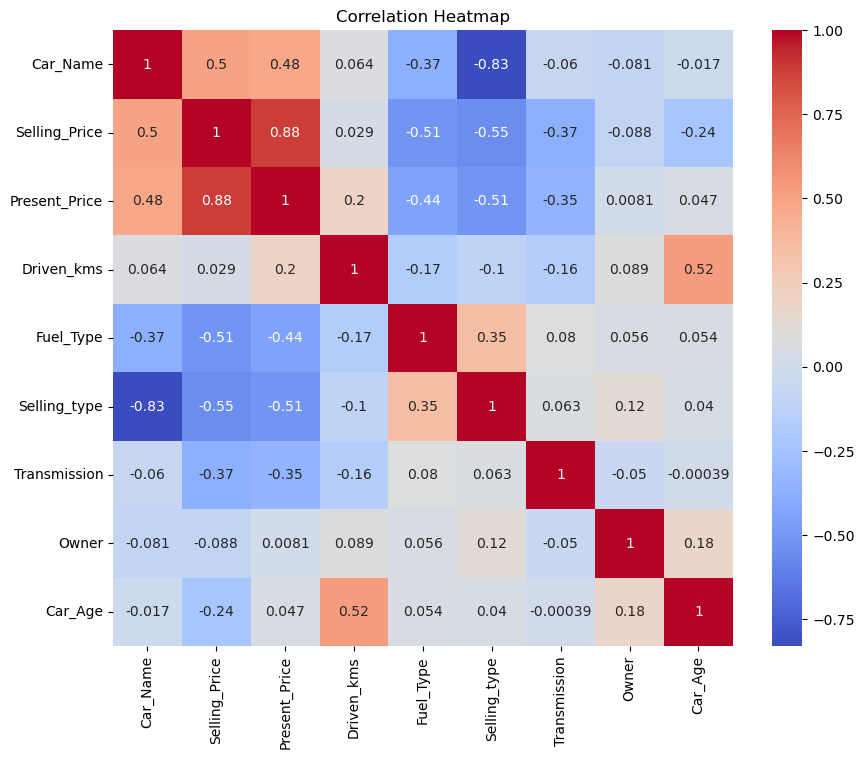

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(car_data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')

Text(0, 0.5, 'Frequency')

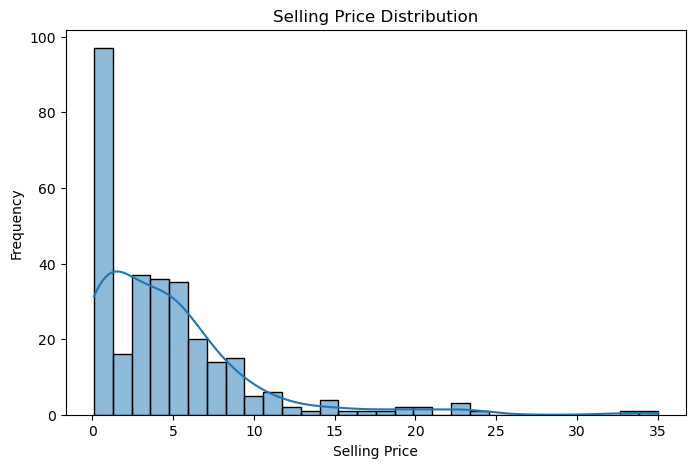

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(car_data['Selling_Price'], bins=30, kde=True)
plt.title('Selling Price Distribution')
plt.xlabel('Selling Price')
plt.ylabel('Frequency')

Text(0.5, 1.0, 'Present Price vs Selling Price')

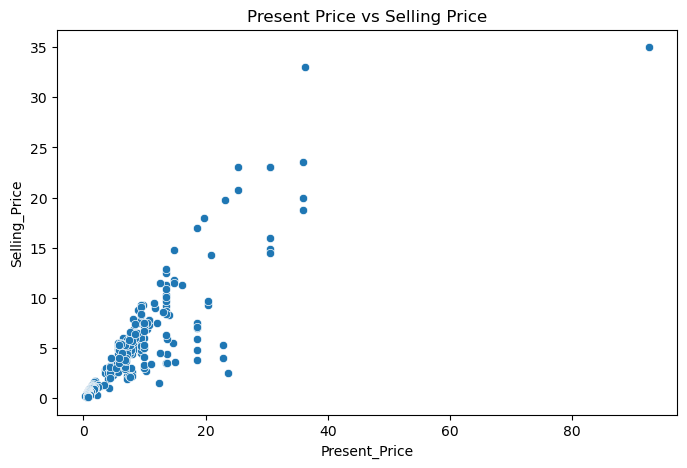

In [11]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=car_data['Present_Price'], y=car_data['Selling_Price'])
plt.title('Present Price vs Selling Price')

In [12]:
# Features
X = car_data.drop('Selling_Price', axis=1)

# Target variable
y = car_data['Selling_Price']

print(X.head())
print(y.head())

   Car_Name  Present_Price  Driven_kms  Fuel_Type  Selling_type  Transmission  \
0        90           5.59       27000          2             0             1   
1        93           9.54       43000          1             0             1   
2        68           9.85        6900          2             0             1   
3        96           4.15        5200          2             0             1   
4        92           6.87       42450          1             0             1   

   Owner  Car_Age  
0      0       12  
1      0       13  
2      0        9  
3      0       15  
4      0       12  
0    3.35
1    4.75
2    7.25
3    2.85
4    4.60
Name: Selling_Price, dtype: float64


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (240, 8)
Testing Data Shape: (61, 8)


In [14]:
# Create model
linear_model = LinearRegression()

# Train model
linear_model.fit(X_train, y_train)

# Predictions
linear_predictions = linear_model.predict(X_test)

In [15]:
# Evaluation metrics
mae = mean_absolute_error(y_test, linear_predictions)
mse = mean_squared_error(y_test, linear_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Results")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

Linear Regression Results
MAE: 1.214732989652875
MSE: 3.5370204237383502
RMSE: 1.8806967920795608
R2 Score: 0.8464540623823604


In [16]:
# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
rf_predictions = rf_model.predict(X_test)

In [17]:
# Evaluation metrics
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

Random Forest Results
MAE: 0.6039508196721313
MSE: 0.8050014222950816
RMSE: 0.8972187148600288
R2 Score: 0.9650540049641015


Text(0.5, 1.0, 'Model Comparison')

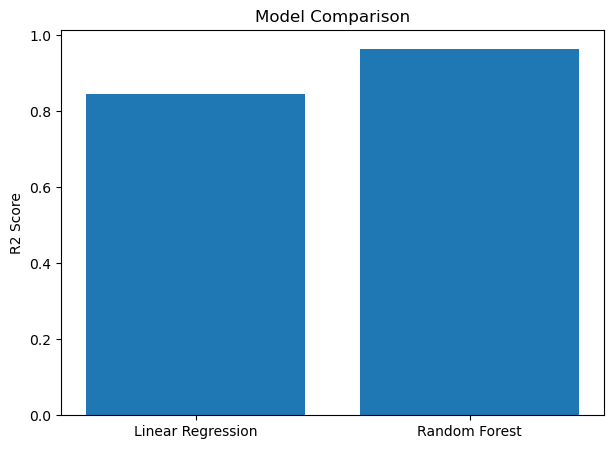

In [18]:
models = ['Linear Regression', 'Random Forest']
r2_scores = [r2, rf_r2]

plt.figure(figsize=(7,5))
plt.bar(models, r2_scores)
plt.ylabel('R2 Score')
plt.title('Model Comparison')

In [22]:
# Example input
sample_data = [[50, 5.59, 27000, 2, 0, 1, 0, 10]]

# Predict using Random Forest
predicted_price = rf_model.predict(sample_data)

print("Predicted Car Price:", predicted_price[0])

Predicted Car Price: 4.1350000000000025


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [20]:
import joblib

# Save model
joblib.dump(rf_model, 'car_price_model.pkl')

print('Model saved successfully!')

Model saved successfully!
